In [16]:
from langgraph.graph import StateGraph , START , END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict , Annotated
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from rich import print

In [2]:
load_dotenv()

True

In [3]:
model = ChatMistralAI(model="mistral-small-2506")

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state : JokeState):

    prompt = f"generate the job on the topic {state["topic"]}"
    response = model.invoke(prompt).content

    return {"joke" : response}

In [7]:
def generate_explanation(state : JokeState):

    prompt = f"write an explanation for the joke: \n {state["joke"]}"
    response = model.invoke(prompt)

    return {"explanation" : response}

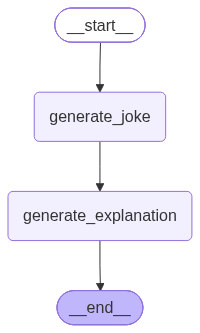

In [10]:
graph = StateGraph(JokeState)

# add node
graph.add_node('generate_joke' , generate_joke)
graph.add_node('generate_explanation' , generate_explanation)

# add edges
graph.add_edge(START , "generate_joke")
graph.add_edge("generate_joke" , "generate_explanation")
graph.add_edge("generate_explanation" , END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow


In [18]:
config = {"configurable" : {"thread_id" : "1"}}
print(workflow.invoke({"topic" : "pizza"} , config=config))

{
    'topic': 'pizza',
    'joke': 'Here’s a comprehensive job description for a **Pizza Chef/Manager** position. This role can be 
tailored for a restaurant, pizzeria, or food service business.\n\n---\n\n### **Job Title: Pizza 
Chef/Manager**\n**Location:** [Your City/State]\n**Employment Type:** Full-time/Part-time\n**Salary:** [Specify 
Range or Competitive Pay]\n**Job ID:** [Optional]\n\n#### **Job Summary:**\nWe are seeking a skilled and passionate
**Pizza Chef/Manager** to join our team. The ideal candidate will have experience in pizza preparation, kitchen 
management, and customer service. You will be responsible for crafting high-quality pizzas, managing kitchen 
operations, and ensuring customer satisfaction.\n\n#### **Key Responsibilities:**\n- Prepare and bake pizzas using 
fresh ingredients, following recipes and quality standards.\n- Manage kitchen staff, including training, 
scheduling, and performance evaluations.\n- Ensure food safety and hygiene standards are met (e.g., food handling, 
sanitation).\n- Maintain inventory of ingredients and supplies, placing orders as needed.\n- Collaborate with the 
management team to develop new pizza recipes and menu items.\n- Handle customer inquiries and complaints 
professionally.\n- Oversee kitchen operations, including equipment maintenance and workflow efficiency.\n- Adhere 
to budget constraints and cost-control measures.\n\n#### **Qualifications & Skills:**\n- Proven experience as a 
**Pizza Chef, Cook, or Kitchen Manager** (1+ years preferred).\n- Strong knowledge of pizza-making techniques 
(dough preparation, sauce, toppings, baking).\n- Ability to work in a fast-paced environment with multitasking 
skills.\n- Leadership and team management experience.\n- Food safety certification (e.g., ServSafe) is a plus.\n- 
Excellent communication and customer service skills.\n\n#### **Benefits (if applicable):**\n- Flexible 
scheduling\n- Employee discounts on food\n- Health insurance (for full-time roles)\n- Opportunities for career 
growth\n\n#### **How to Apply:**\nInterested candidates should submit a resume and cover letter to 
[Email/Application Link]. Please include any relevant certifications or references.\n\n---\n\nWould you like this 
tailored for a specific type of pizza (e.g., Neapolitan, New York-style, etc.) or adjusted for a different role 
(e.g., Pizza Delivery Driver, Pizza Oven Specialist)? Let me know! 🍕',
    'explanation': AIMessage(
        content='The joke in this job description lies in its absurdly formal and overly detailed presentation of a
role that is, at its core, about making and managing pizza. The humor comes from the contrast between the serious, 
corporate-style job posting and the relatively simple, often informal nature of pizza-making jobs.\n\nHere’s why 
it’s funny:\n\n1. **Overly Formal Language for a Casual Job** – Most pizza chef/manager roles are found in small 
pizzerias, food trucks, or local restaurants where job descriptions are usually brief and informal. The use of 
terms like "comprehensive job description," "key responsibilities," and "performance evaluations" makes it sound 
like a high-powered corporate role rather than a job that might involve tossing dough and dealing with picky 
customers.\n\n2. **Unnecessary Specificity** – The breakdown of duties (e.g., "collaborate with the management team
to develop new pizza recipes") is exaggerated, as if the job requires a PhD in pizza innovation rather than just 
making good pies.\n\n3. **Pretentious Qualifications** – The mention of "food safety certification (e.g., ServSafe)
is a plus" is funny because, while certifications are important, the tone makes it sound like a luxury rather than 
a basic requirement. The "1+ years preferred" experience is also amusingly formal for a job that might just require
"being able to cook pizza."\n\n4. **Benefits That Are Almost Mocking** – Listing "employee discounts on food" as a 
benefit is hilarious because, of course, pizza workers alr

In [17]:
info = workflow.get_state(config)
print(info)

StateSnapshot(
    values={
        'topic': 'pizza',
        'joke': 'Here’s a **job description** for a **Pizza Chef/Manager** role. You can customize it based on the 
specific requirements of the position:\n\n---\n\n### **Job Title: Pizza Chef/Manager**\n**Location:** [Your 
City/Location]\n**Employment Type:** [Full-time/Part-time/Contract]\n**Salary:** [Competitive/As per industry 
standards]\n\n### **Job Description:**\nWe are looking for a passionate and skilled **Pizza Chef/Manager** to join 
our team. The ideal candidate will have experience in pizza preparation, kitchen management, and customer service. 
You will be responsible for creating delicious pizzas, ensuring food quality, managing kitchen operations, and 
maintaining a clean and efficient workspace.\n\n### **Key Responsibilities:**\n- Prepare and cook high-quality 
pizzas, pasta, and other Italian dishes.\n- Maintain food safety and hygiene standards.\n- Manage kitchen staff, 
including training and scheduling.\n- Ensure timely delivery of orders (if applicable).\n- Handle customer 
inquiries and complaints professionally.\n- Monitor inventory and place orders for ingredients.\n- Maintain a clean
and organized kitchen.\n- Assist in menu development and recipe testing.\n\n### **Requirements:**\n- Proven 
experience as a **Pizza Chef, Cook, or Kitchen Manager** (preferred).\n- Knowledge of pizza dough preparation, 
sauces, and toppings.\n- Strong leadership and team management skills.\n- Excellent communication and customer 
service skills.\n- Ability to work in a fast-paced environment.\n- Food handler’s certification (if required by 
local regulations).\n\n### **Preferred Qualifications:**\n- Culinary degree or relevant training.\n- Experience in 
a pizzeria or Italian restaurant.\n- Basic accounting or inventory management skills.\n\n### **Benefits:**\n- 
Competitive salary and performance bonuses.\n- Flexible work schedule.\n- Career growth opportunities.\n- Employee 
discounts on food.\n\n### **How to Apply:**\nInterested candidates should submit their **resume, cover letter, and 
any relevant certifications** to [Your Email/Application Link].\n\n---\n\nWould you like any modifications, such as
a **Pizza Delivery Driver** job description or a **Pizza Restaurant Manager** role instead? Let me know! 🍕',
        'explanation': AIMessage(
            content='The humor in this joke lies in the **absurdly specific and overly formal** way it presents a 
job description for a **Pizza Chef/Manager**. Here’s why it’s funny:\n\n1. **Unnecessary Formality** – Job 
descriptions are usually serious and professional, but this one treats a pizza chef like a high-powered executive. 
The use of corporate jargon ("key responsibilities," "performance bonuses," "career growth opportunities") for a 
role that’s traditionally seen as casual or blue-collar makes it ridiculous.\n\n2. **Overqualified Requirements** –
The "preferred qualifications" (culinary degree, accounting skills) are exaggerated for a job that, in reality, 
might just require knowing how to toss dough and follow a recipe. The idea of a pizza chef needing a "food 
handler’s certification" (which is actually real in many places) is played up for comedic effect.\n\n3. **Silly Job
Title** – "Pizza Chef/Manager" sounds like a made-up corporate hybrid role. In reality, many small pizzerias don’t 
have such a structured hierarchy, so the title itself is amusingly pretentious.\n\n4. **Benefits That Aren’t Really
Benefits** – "Employee discounts on food" is a common perk, but listing it as a "benefit" in a formal job 
description makes it sound like a major selling point, which is funny because it’s something most pizza workers 
already get.\n\n5. **The Absurd Follow-Up** – The punchline comes at the end: *"Would you like any modifications, 
such as a **Pizza Delivery Driver** job description or a **Pizza Restaurant Manager** role instead? Let me know! 
🍕"* This implies that the writer is treating pizza-related jobs a

In [21]:
config2 = {"configurable" : {"thread_id" : "2"}}
print(workflow.invoke({"topic" : "Pasta"} , config=config2))

{
    'topic': 'Pasta',
    'joke': 'Certainly! Below is a **Job Description** for a **Pasta Chef** position. You can customize it further 
based on the specific requirements of the role.\n\n---\n\n### **Job Title: Pasta Chef**\n**Location:** [City, 
Country]\n**Employment Type:** [Full-time/Part-time/Contract]\n**Experience Level:** 
[Entry-level/Mid-level/Senior]\n\n#### **Job Summary:**\nWe are seeking a skilled and passionate **Pasta Chef** to 
join our culinary team. The ideal candidate will have expertise in preparing fresh, high-quality pasta dishes, 
including traditional and innovative recipes. You will be responsible for creating delicious pasta meals, ensuring 
consistency in taste and presentation, and maintaining a clean and organized kitchen.\n\n#### **Key 
Responsibilities:**\n- Prepare fresh pasta from scratch, including dough, sauces, and fillings.\n- Follow recipes 
and adjust seasoning to maintain consistent quality.\n- Cook pasta dishes to perfection, ensuring proper texture 
and doneness.\n- Maintain a clean and organized workstation, adhering to food safety standards.\n- Assist in menu 
planning and recipe development.\n- Train and supervise kitchen staff on pasta preparation techniques.\n- Manage 
inventory of pasta ingredients and equipment.\n- Collaborate with the culinary team to ensure smooth kitchen 
operations.\n- Provide excellent customer service by engaging with guests when needed.\n\n#### **Qualifications & 
Skills:**\n- Proven experience as a **Pasta Chef** or similar role in a professional kitchen.\n- Strong knowledge 
of Italian cuisine and pasta-making techniques.\n- Ability to work efficiently in a fast-paced environment.\n- 
Excellent knife skills and attention to detail.\n- Strong communication and teamwork skills.\n- Food safety 
certification (e.g., ServSafe) is a plus.\n- Creativity in developing new pasta dishes.\n\n#### **Work 
Schedule:**\n- [Specify shifts, e.g., evenings, weekends, or rotating schedules]\n\n#### **Benefits (if 
applicable):**\n- Competitive salary\n- Health insurance\n- Meal discounts\n- Career growth opportunities\n\n#### 
**How to Apply:**\nInterested candidates should submit their resume and a cover letter to [email address] or apply 
online at [website link].\n\n---\n\nWould you like any modifications, such as a focus on a specific cuisine (e.g., 
Italian, Asian fusion) or a different job level (e.g., Executive Pasta Chef)? Let me know how I can refine this 
further!',
    'explanation': AIMessage(
        content='The joke in this scenario likely revolves around the absurdity or specificity of the job title 
**"Pasta Chef"**—a role that, while real in professional kitchens, is often overlooked or taken for granted in 
everyday contexts.\n\n### **Explanation of the Joke:**\n1. **Overly Formal for a Simple Role:**\n   - The joke 
plays on the idea that a "Pasta Chef" is a legitimate, specialized position, but in reality, many people assume 
anyone can boil noodles and toss them with sauce. The detailed job description (with responsibilities like "adjust 
seasoning" and "train staff") highlights how undervalued pasta-making can be, despite requiring skill.\n\n2. 
**Satire of Corporate Job Descriptions:**\n   - The overly structured, corporate-style job posting (with sections 
like "Key Responsibilities" and "Benefits") contrasts humorously with the mundane nature of pasta preparation. It 
mocks how even simple jobs can be bureaucratized.\n\n3. **Cultural Stereotypes:**\n   - The role leans into the 
stereotype of Italian cuisine being synonymous with pasta, making the "Pasta Chef" sound like a high-status 
position (like a "Sushi Chef" or "Pastry Chef"). The joke is that while pasta is beloved, the chef who makes it is 
rarely given the same prestige.\n\n4. **Absurd Specialization:**\n   - The idea of someone being *only* a "Pasta 
Chef" (as opposed to a general line cook) is inherently funny because it implies pasta is so complex that it 
requires a dedicated 

In [22]:
print(workflow.get_state(config2))

StateSnapshot(
    values={
        'topic': 'Pasta',
        'joke': 'Certainly! Below is a **Job Description** for a **Pasta Chef** position. You can customize it 
further based on the specific requirements of the role.\n\n---\n\n### **Job Title: Pasta Chef**\n**Location:** 
[City, Country]\n**Employment Type:** [Full-time/Part-time/Contract]\n**Experience Level:** 
[Entry-level/Mid-level/Senior]\n\n#### **Job Summary:**\nWe are seeking a skilled and passionate **Pasta Chef** to 
join our culinary team. The ideal candidate will have expertise in preparing fresh, high-quality pasta dishes, 
including traditional and innovative recipes. You will be responsible for creating delicious pasta meals, ensuring 
consistency in taste and presentation, and maintaining a clean and organized kitchen.\n\n#### **Key 
Responsibilities:**\n- Prepare fresh pasta from scratch, including dough, sauces, and fillings.\n- Follow recipes 
and adjust seasoning to maintain consistent quality.\n- Cook pasta dishes to perfection, ensuring proper texture 
and doneness.\n- Maintain a clean and organized workstation, adhering to food safety standards.\n- Assist in menu 
planning and recipe development.\n- Train and supervise kitchen staff on pasta preparation techniques.\n- Manage 
inventory of pasta ingredients and equipment.\n- Collaborate with the culinary team to ensure smooth kitchen 
operations.\n- Provide excellent customer service by engaging with guests when needed.\n\n#### **Qualifications & 
Skills:**\n- Proven experience as a **Pasta Chef** or similar role in a professional kitchen.\n- Strong knowledge 
of Italian cuisine and pasta-making techniques.\n- Ability to work efficiently in a fast-paced environment.\n- 
Excellent knife skills and attention to detail.\n- Strong communication and teamwork skills.\n- Food safety 
certification (e.g., ServSafe) is a plus.\n- Creativity in developing new pasta dishes.\n\n#### **Work 
Schedule:**\n- [Specify shifts, e.g., evenings, weekends, or rotating schedules]\n\n#### **Benefits (if 
applicable):**\n- Competitive salary\n- Health insurance\n- Meal discounts\n- Career growth opportunities\n\n#### 
**How to Apply:**\nInterested candidates should submit their resume and a cover letter to [email address] or apply 
online at [website link].\n\n---\n\nWould you like any modifications, such as a focus on a specific cuisine (e.g., 
Italian, Asian fusion) or a different job level (e.g., Executive Pasta Chef)? Let me know how I can refine this 
further!',
        'explanation': AIMessage(
            content='The joke in this scenario likely revolves around the absurdity or specificity of the job title
**"Pasta Chef"**—a role that, while real in professional kitchens, is often overlooked or taken for granted in 
everyday contexts.\n\n### **Explanation of the Joke:**\n1. **Overly Formal for a Simple Role:**\n   - The joke 
plays on the idea that a "Pasta Chef" is a legitimate, specialized position, but in reality, many people assume 
anyone can boil noodles and toss them with sauce. The detailed job description (with responsibilities like "adjust 
seasoning" and "train staff") highlights how undervalued pasta-making can be, despite requiring skill.\n\n2. 
**Satire of Corporate Job Descriptions:**\n   - The overly structured, corporate-style job posting (with sections 
like "Key Responsibilities" and "Benefits") contrasts humorously with the mundane nature of pasta preparation. It 
mocks how even simple jobs can be bureaucratized.\n\n3. **Cultural Stereotypes:**\n   - The role leans into the 
stereotype of Italian cuisine being synonymous with pasta, making the "Pasta Chef" sound like a high-status 
position (like a "Sushi Chef" or "Pastry Chef"). The joke is that while pasta is beloved, the chef who makes it is 
rarely given the same prestige.\n\n4. **Absurd Specialization:**\n   - The idea of someone being *only* a "Pasta 
Chef" (as opposed to a general line cook) is inherently funny because it implies pasta is 

Time Travel: It is used for debugging in which we basically take the checkpoint_id's of the nodes that are executed from somewhere in workflow.

In [23]:
workflow.get_state({"configurable" : {"thread_id" : "1" , "checkpoint_id" : "1f188f3d-7e14-6aeb-8006-263a8eca5d80"}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Here’s a **job description** for a **Pizza Chef/Manager** role. You can customize it based on the specific requirements of the position:\n\n---\n\n### **Job Title: Pizza Chef/Manager**\n**Location:** [Your City/Location]\n**Employment Type:** [Full-time/Part-time/Contract]\n**Salary:** [Competitive/As per industry standards]\n\n### **Job Description:**\nWe are looking for a passionate and skilled **Pizza Chef/Manager** to join our team. The ideal candidate will have experience in pizza preparation, kitchen management, and customer service. You will be responsible for creating delicious pizzas, ensuring food quality, managing kitchen operations, and maintaining a clean and efficient workspace.\n\n### **Key Responsibilities:**\n- Prepare and cook high-quality pizzas, pasta, and other Italian dishes.\n- Maintain food safety and hygiene standards.\n- Manage kitchen staff, including training and scheduling.\n- Ensure timely delivery of orders

In [24]:
workflow.invoke(None , {"configurable" : {"thread_id" : "1" , "checkpoint_id" : "1f188f3d-7e14-6aeb-8006-263a8eca5d80"}})

{'topic': 'pizza',
 'joke': 'Here’s a **job description** for a **Pizza Chef/Manager** role. You can customize it based on the specific requirements of the position:\n\n---\n\n### **Job Title: Pizza Chef/Manager**\n**Location:** [Your City/Location]\n**Employment Type:** [Full-time/Part-time/Contract]\n**Salary:** [Competitive/As per industry standards]\n\n### **Job Description:**\nWe are looking for a passionate and skilled **Pizza Chef/Manager** to join our team. The ideal candidate will have experience in pizza preparation, kitchen management, and customer service. You will be responsible for creating delicious pizzas, ensuring food quality, managing kitchen operations, and maintaining a clean and efficient workspace.\n\n### **Key Responsibilities:**\n- Prepare and cook high-quality pizzas, pasta, and other Italian dishes.\n- Maintain food safety and hygiene standards.\n- Manage kitchen staff, including training and scheduling.\n- Ensure timely delivery of orders (if applicable).\n-

In [26]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Here’s a **job description** for a **Pizza Chef/Manager** role. You can customize it based on the specific requirements of the position:\n\n---\n\n### **Job Title: Pizza Chef/Manager**\n**Location:** [Your City/Location]\n**Employment Type:** [Full-time/Part-time/Contract]\n**Salary:** [Competitive/As per industry standards]\n\n### **Job Description:**\nWe are looking for a passionate and skilled **Pizza Chef/Manager** to join our team. The ideal candidate will have experience in pizza preparation, kitchen management, and customer service. You will be responsible for creating delicious pizzas, ensuring food quality, managing kitchen operations, and maintaining a clean and efficient workspace.\n\n### **Key Responsibilities:**\n- Prepare and cook high-quality pizzas, pasta, and other Italian dishes.\n- Maintain food safety and hygiene standards.\n- Manage kitchen staff, including training and scheduling.\n- Ensure timely delivery of order

Updating of the State

In [ ]:
workflow.update_state({"configurable" : {"thread_id" : "1" , "checkpoint_id" : "1f188f29-3d20-6eed-bfff-b71363f934a4" , "checkpoint_ns" : ""}} , {"topic" : "somosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1890e7-01ae-65f5-8000-d8e30d3a13db'}}

In [32]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'somosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1890e7-01ae-65f5-8000-d8e30d3a13db'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-07-26T16:24:12.855448+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f188f29-3d20-6eed-bfff-b71363f934a4'}}, tasks=(PregelTask(id='ad4bd206-8154-63c8-8d02-02432939c269', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Here’s a **job description** for a **Pizza Chef/Manager** role. You can customize it based on the specific requirements of the position:\n\n---\n\n### **Job Title: Pizza Chef/Manager**\n**Location:** [Your City/Location]\n**Employment Type:** [Full-time/Part-time/Contract]\n**Salary:** [Competitive/As per industry standards]\n\n

In [34]:
workflow.invoke(None , {"configurable" : {"thread_id" : "1" , "checkpoint_id" : "1f1890e7-01ae-65f5-8000-d8e30d3a13db" }})

{'topic': 'somosa',
 'joke': 'Here’s a **job description** for a role related to **Samosas** (assuming it’s about a food business, catering, or food production):\n\n---\n\n### **Job Title: Samosa Production & Sales Executive**\n**Location:** [City/Remote]\n**Employment Type:** Full-time/Part-time\n**Industry:** Food & Beverage\n\n#### **Job Summary:**\nWe are looking for a passionate and skilled **Samosa Production & Sales Executive** to join our team. The ideal candidate will be responsible for preparing high-quality samosas, managing inventory, and driving sales through effective customer engagement. This role is perfect for someone with a love for Indian street food and a knack for business development.\n\n#### **Key Responsibilities:**\n- Prepare and assemble samosas with fresh, high-quality ingredients.\n- Maintain hygiene and food safety standards in the kitchen.\n- Manage inventory of raw materials and finished products.\n- Assist in packaging and distribution of samosas to cust

In [35]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'somosa', 'joke': 'Here’s a **job description** for a role related to **Samosas** (assuming it’s about a food business, catering, or food production):\n\n---\n\n### **Job Title: Samosa Production & Sales Executive**\n**Location:** [City/Remote]\n**Employment Type:** Full-time/Part-time\n**Industry:** Food & Beverage\n\n#### **Job Summary:**\nWe are looking for a passionate and skilled **Samosa Production & Sales Executive** to join our team. The ideal candidate will be responsible for preparing high-quality samosas, managing inventory, and driving sales through effective customer engagement. This role is perfect for someone with a love for Indian street food and a knack for business development.\n\n#### **Key Responsibilities:**\n- Prepare and assemble samosas with fresh, high-quality ingredients.\n- Maintain hygiene and food safety standards in the kitchen.\n- Manage inventory of raw materials and finished products.\n- Assist in packaging and distributi